In [1]:
import json
import requests
import pandas as pd

# Charger les données
base_url = "https://api-base-fastapi-mpt-dkhjb0cydga2aydc.canadacentral-01.azurewebsites.net"
api_key = ""
with open('../api.json', 'r') as file:
    api_key = json.load(file)["GH_API_KEY"]

def get_call(paths,url=base_url, params=None, header=None):
    url = f"{base_url}/{paths}"
    response = requests.get(url, params=params, headers=header)
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 403:
        print("La patience est d'or. Enculé")
        response = requests.get(url, params=params, headers=header)
        return response.json()
    else:
        print(f"Error: {response.status_code} - {response.json().get('message', 'Unknown error')}")
        return None
repositories = get_call(paths="show_data",params={"page_size":10000,"page":1})

In [2]:
df = pd.DataFrame(repositories['data'])
df.to_pickle("repositories_data.pkl")
# df = df['language'].value_counts()[df['language'].value_counts()>10]

In [3]:
import pandas as pd
df = pd.read_pickle("repositories_data.pkl")
len(df)

10000

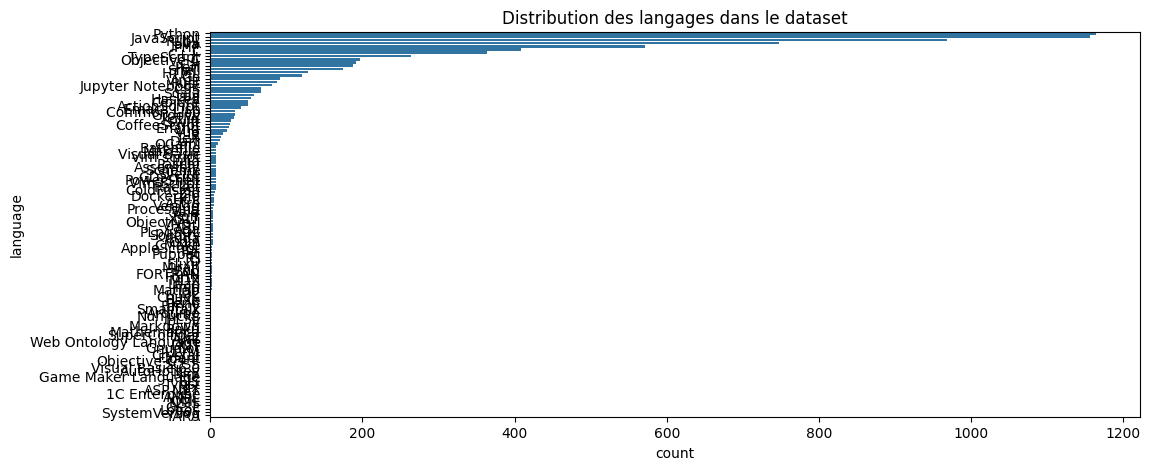

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.countplot(y=df["language"], order=df["language"].value_counts().index)
plt.title("Distribution des langages dans le dataset")
plt.show()

In [6]:
from train import train_log
acc = train_log(df,model_name="gradient_boosting",epochs=10, batch_size=256)
print(f"Modèle entraîné avec une accuracy de {acc}")


2025/02/25 22:25:38 INFO mlflow.tracking.fluent: Experiment with name 'Train gradient_boosting' does not exist. Creating a new experiment.
📈 Entraînement des epochs:   0%|          | 0/10 [00:00<?, ?it/s]


🔄 Epoch 1/10...


📈 Entraînement des epochs:  10%|█         | 1/10 [00:05<00:52,  5.83s/it]

🎯 Accuracy: 0.1320

🔄 Epoch 2/10...


📈 Entraînement des epochs:  20%|██        | 2/10 [00:11<00:46,  5.82s/it]

...

🎯 Accuracy: 0.1307

🔄 Epoch 10/10...


📈 Entraînement des epochs: 100%|██████████| 10/10 [00:58<00:00,  5.86s/it]

🎯 Accuracy: 0.1307



2025/02/25 22:26:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/02/25 22:26:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: gradient_boosting, version 1
c:\Users\TAN\Documents\Big_Data_MLOps_Github_API\src\train.py:88: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


✅ Modèle gradient_boosting enregistré en version 1
Modèle gradient_boosting version 1 mis en production sur MLflow Serving!
Nouvelle variable MODEL_NAME=gradient_boosting enregistrée dans .env
🏃 View run defiant-ape-464 at: http://127.0.0.1:8083/#/experiments/649986330737236926/runs/d9a8702025c147d0a431af7a68f015c3
🧪 View experiment at: http://127.0.0.1:8083/#/experiments/649986330737236926
Modèle entraîné avec une accuracy de 0.13067694944301628
